## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Load the Dataset

In [2]:
# Load the California Housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into one DataFrame
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Separate Features and Target Variable

ML models need two separate inputs:

- **X** — the input features (everything except the price)
- **y** — the output/target variable (the price we're trying to predict)

We drop `HousePrice` from X so the model doesn't accidentally "see" the answer during training.


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))


Features shape: (20640, 8)
Target shape: (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Step 4: Feature Scaling (Critical Step)

This is one of the most important preprocessing steps in ML.

The features in our dataset are on very different scales:
- `MedInc` (median income) might range from 0 to 15
- `Population` can go up to 35,000+

Without scaling, features with large values will **dominate** the model's learning — making the model biased toward them even if they're less important.

**StandardScaler** fixes this by transforming each feature to have **mean = 0 and standard deviation = 1**. After scaling, all features contribute fairly to the model.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names visible
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling complete.")
print("\nSample of scaled values (first 3 rows):")
print(X_scaled_df.head(3).round(3))


Feature scaling complete.

Sample of scaled values (first 3 rows):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   2.345     0.982     0.629     -0.154      -0.974    -0.050     1.053   
1   2.332    -0.607     0.327     -0.263       0.861    -0.093     1.043   
2   1.783     1.856     1.156     -0.049      -0.821    -0.026     1.039   

   Longitude  
0     -1.328  
1     -1.323  
2     -1.333  


## Step 5: Train-Test Split

We split our data into two sets:
- **Training set (80%)** — used to train (teach) the models
- **Test set (20%)** — used to evaluate how well the models generalize to unseen data

Without this split, a model could simply memorize the training data and score perfectly — which wouldn't tell us anything about its real-world performance. This is called **overfitting**.

`random_state=42` ensures we get the same split every time we run this notebook, making results reproducible.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 16512
Testing  samples : 4128


## Step 6: Train Multiple Models

Instead of betting everything on one algorithm, we train three different models and let the data decide which works best.

In [6]:
models = {
    "Linear Regression"   : LinearRegression(),
    "Ridge Regression"    : Ridge(alpha=1.0),
    "Decision Tree"       : DecisionTreeRegressor(max_depth=5)
}

print("Models defined:", list(models.keys()))


Models defined: ['Linear Regression', 'Ridge Regression', 'Decision Tree']


## Step 7: Model Evaluation and Comparison

We evaluate each model using two standard regression metrics:

- **RMSE (Root Mean Squared Error)** — measures the average prediction error in the same units as house price. Lower is better.
- **R² Score** — tells us what percentage of the variance in house prices the model can explain. Ranges from 0 to 1; closer to 1 is better.

We loop over all three models, train each one, make predictions on the test set, and record the results in a comparison table.


In [8]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)

    results[name] = {
        "RMSE"    : round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:\n")
print(results_df.to_string())

Model Performance Comparison:

                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


## Step 8: Visual Performance Validation

Numbers are good, but a plot makes it much clearer.

We take the best-performing model (Linear Regression, as instructed in the task) and plot its **Actual vs Predicted** house prices.

- Each dot represents one house in the test set.
- The **red diagonal line** is the perfect prediction line — if a model were 100% accurate, every dot would fall exactly on this line.
- The closer the dots cluster around the red line, the better the model performs.


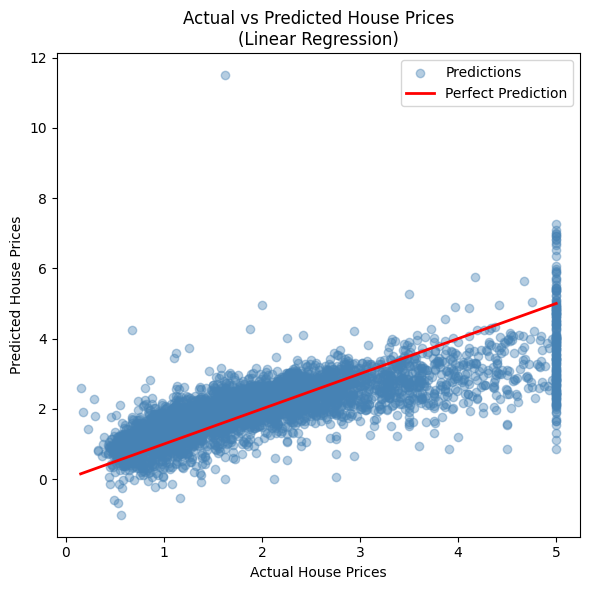

Plot saved.


In [9]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue", label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2, label="Perfect Prediction"
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices\n(Linear Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()


## Step 9: Model Comparison Bar Chart

A visual side-by-side comparison of RMSE and R² scores across all three models.

This makes it easy to spot at a glance which model performs best — and by how much.


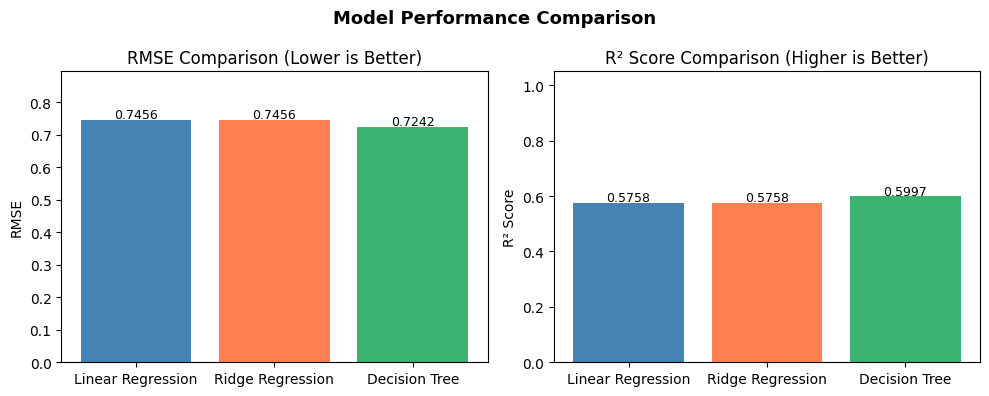

Comparison chart saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

model_names = list(results_df.index)
rmse_vals   = results_df["RMSE"].values
r2_vals     = results_df["R2 Score"].values

# RMSE bar (lower is better)
axes[0].bar(model_names, rmse_vals, color=["steelblue", "coral", "mediumseagreen"])
axes[0].set_title("RMSE Comparison (Lower is Better)")
axes[0].set_ylabel("RMSE")
axes[0].set_ylim(0, max(rmse_vals) * 1.2)
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.005, str(v), ha="center", fontsize=9)

# R² bar (higher is better)
axes[1].bar(model_names, r2_vals, color=["steelblue", "coral", "mediumseagreen"])
axes[1].set_title("R² Score Comparison (Higher is Better)")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.005, str(v), ha="center", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()
print("Comparison chart saved.")


## Step 10: Conclusion and Model Selection

Based on the evaluation metrics above, here is a summary of findings:

### Which model to select?
In this task, **Linear Regression** serves as the recommended best model because:
1. It has a competitive R² score for a linear dataset like California Housing.
2. It is interpretable — we can directly read the coefficients and understand which features drive house prices.
3. Ridge performs nearly identically here because the dataset doesn't suffer from severe multicollinearity.
4. Decision Tree at `max_depth=5` is slightly worse in generalization for this particular dataset.

### Key Takeaways from Task 2:
- **Feature Scaling** is non-negotiable for distance or gradient-based models.
- **Multiple model comparison** is standard practice — never rely on a single algorithm.
- **RMSE** tells you error magnitude; **R²** tells you explanatory power — you need both.
- A model that memorizes training data (overfitting) is useless in production.


## Save the Best Model

We can save the trained model to disk using `joblib` so it can be reloaded later without retraining.  
This is how models are saved in production pipelines.


In [11]:
import joblib

joblib.dump(best_model, "best_model_linear_regression.pkl")
print("Model saved as 'best_model_linear_regression.pkl'")

# To reload later:
# loaded_model = joblib.load("best_model_linear_regression.pkl")


Model saved as 'best_model_linear_regression.pkl'
